In [62]:
# Cell 1: Setup and imports
%env XLA_PYTHON_CLIENT_PREALLOCATE=False
import jax.numpy as jnp
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =============================
# Load all PKL files
# =============================
DIR = "./2_/"
results_list = []
titles_list = []
dim_list = []
trueZ_list = []  # new list to store true Z per dimension

for file in os.listdir(DIR):
    if file.endswith(".pkl"):
        # Load pickle
        with open(os.path.join(DIR, file), "rb") as f:
            my_pkl = pickle.load(f)

        # Append 5th element of 'res'
        results_list.append(my_pkl['res'][4])
        titles_list.append(file)

        # Read dimension directly from the pickle config
        dim_val = my_pkl['config']['dim']
        dim_list.append(dim_val)

        # Read true_Z for this dimension from pickle
        trueZ_list.append(float(jnp.exp(my_pkl['config']['logZ'])))

# =============================
# Build pandas DataFrame with trueZ per dimension
# =============================
df = pd.DataFrame({
    "filename": titles_list,
    "dim": dim_list,
    "res5": results_list,
    "trueZ": trueZ_list
})

# Sort by dimension for convenience
df = df.sort_values("dim").reset_index(drop=True)

print(df.head())

# =============================
# Example: iterate over dim and do something
# =============================
for dim_val, group in df.groupby("dim"):
    print(f"dim={dim_val}: number of entries = {len(group)}, shapes = {[r.shape if hasattr(r, 'shape') else None for r in group['res5']]}")

# =============================
# Concatenate results for each dimension
# =============================
df_concat = (
    df.groupby("dim")["res5"]
      .apply(lambda x: np.concatenate(x.values, axis=0))
      .reset_index()
      .rename(columns={"res5": "res5_concat"})
)
df_trueZ = df[['dim', 'trueZ']].drop_duplicates()
df_concat = df_concat.merge(df_trueZ, on='dim', how='left')

env: XLA_PYTHON_CLIENT_PREALLOCATE=False
                           filename  dim  \
0  2__eps0.0500_2.py_0311174628.pkl    1   
1  2__eps0.0500_2.py_0311174636.pkl    1   
2  2__eps0.0500_2.py_0311174631.pkl    1   
3  2__eps0.0500_2.py_0311174647.pkl    1   
4  2__eps0.0500_2.py_0311174639.pkl    1   

                                                res5     trueZ  
0  [[-0.27773216, 0.0], [-0.15616488, 0.0], [-0.1...  0.670334  
1  [[-0.3514847, 0.0], [-1.1704398, 0.0], [-0.371...  0.670334  
2  [[-0.24678658, 0.0], [-0.45617652, 0.0], [-0.6...  0.670334  
3  [[-0.4017789, 0.0], [-0.6779831, 0.0], [-0.199...  0.670334  
4  [[-0.3954935, 0.0], [-0.377263, 0.0], [-0.2779...  0.670334  
dim=1: number of entries = 10, shapes = [(20, 2), (20, 2), (20, 2), (20, 2), (20, 2), (20, 2), (20, 2), (20, 2), (20, 2), (20, 2)]
dim=5: number of entries = 10, shapes = [(20, 4), (20, 4), (20, 4), (20, 4), (20, 4), (20, 4), (20, 4), (20, 4), (20, 4), (20, 4)]
dim=10: number of entries = 10, shapes = [

In [63]:
df

,filename,dim,res5,trueZ
0,2__eps0.0500_2.py_0311174628.pkl,1,"[[-0.27773216, 0.0], [-0.15616488, 0.0], [-0.1...",0.670334
1,2__eps0.0500_2.py_0311174636.pkl,1,"[[-0.3514847, 0.0], [-1.1704398, 0.0], [-0.371...",0.670334
2,2__eps0.0500_2.py_0311174631.pkl,1,"[[-0.24678658, 0.0], [-0.45617652, 0.0], [-0.6...",0.670334
3,2__eps0.0500_2.py_0311174647.pkl,1,"[[-0.4017789, 0.0], [-0.6779831, 0.0], [-0.199...",0.670334
4,2__eps0.0500_2.py_0311174639.pkl,1,"[[-0.3954935, 0.0], [-0.377263, 0.0], [-0.2779...",0.670334
5,2__eps0.0500_2.py_0311174623.pkl,1,"[[-0.27480567, 0.0], [-0.46979767, 0.0], [-0.3...",0.670334
6,2__eps0.0500_2.py_0311174634.pkl,1,"[[-0.4724826, 0.0], [-0.5007004, 0.0], [-0.553...",0.670334
7,2__eps0.0500_2.py_0311174642.pkl,1,"[[-0.15620984, 0.0], [-0.45381033, 0.0], [-0.5...",0.670334
8,2__eps0.0500_2.py_0311174644.pkl,1,"[[-0.37996617, 0.0], [-0.4607747, 0.0], [-0.24...",0.670334
9,2__eps0.0500_2.py_0311174626.pkl,1,"[[-0.33326533, 0.0], [-0.34994307, 0.0], [-0.2...",0.670334


In [64]:
# Cell 2: Helper functions

def rel_error(x, y):
    return jnp.abs((x - y) / y)


def computeZ_from_data(my_pkl):
    logZoverZs = my_pkl['res'][4]
    ZoverZs = jnp.exp(logZoverZs)
    Z = jnp.prod(ZoverZs, axis=-1)
    return Z


def Z_med(logZoverZs):
    ZoverZs = jnp.exp(logZoverZs)
    medians = jnp.median(ZoverZs, axis=-1)
    return jnp.prod(medians, axis=-1)


def concatenate_logZoverZs(my_pkls, T):
    number_of_pkls = len(my_pkls)
    in_parallel = 1
    if my_pkls:
        in_parallel = my_pkls[0]['res'][4].shape[0]
    logZoverZs = np.zeros(shape=(number_of_pkls, in_parallel, T))
    for idx, pkl in enumerate(my_pkls):
        logZoverZs[idx] = pkl['res'][4]
    logZoverZs = logZoverZs.reshape((-1, T))
    return logZoverZs

In [65]:
df_concat

,dim,res5_concat,trueZ
0,1,"[[-0.27773216, 0.0], [-0.15616488, 0.0], [-0.1...",0.670334
1,5,"[[-1.7042857, -0.030765006, 0.0, 0.0], [-1.659...",0.182079
2,10,"[[-2.0531979, -1.659977, -0.033923127, 0.0, 0....",0.028457


In [66]:
# Cell 4: Compute products and relative errors per dim
df_concat["prod_exp"] = df_concat["res5_concat"].apply(lambda arr: jnp.prod(jnp.exp(arr), axis=-1))
df_concat["rel_error"] = df_concat.apply(lambda row: rel_error(row["prod_exp"], row["trueZ"]), axis=1)

print(df_concat)

   dim                                        res5_concat     trueZ  \
0    1  [[-0.27773216, 0.0], [-0.15616488, 0.0], [-0.1...  0.670334   
1    5  [[-1.7042857, -0.030765006, 0.0, 0.0], [-1.659...  0.182079   
2   10  [[-2.0531979, -1.659977, -0.033923127, 0.0, 0....  0.028457   

                                            prod_exp  \
0  [0.7574997, 0.85541815, 0.8609974, 0.55680823,...   
1  [0.17639123, 0.15830936, 0.19146448, 0.1730438...   
2  [0.023586094, 0.025762029, 0.02496136, 0.02178...   

                                           rel_error  
0  [0.13003357, 0.27610773, 0.2844308, 0.16935678...  
1  [0.03123929, 0.130547, 0.051544745, 0.04962349...  
2  [0.17115465, 0.09468955, 0.12282608, 0.2345589...  


In [67]:

# fixed epsilon
eps = 0.1

expanded_records = []

for _, row in df_concat.iterrows():
    dim_val = row["dim"]
    true_Z = row["trueZ"]  # dimension-specific true Z
    res5 = row["res5_concat"]  # shape (total_estimates_d, T)
    prod_exp = np.prod(np.exp(res5), axis=-1)
    rel_error_arr = rel_error(prod_exp, true_Z)

    total_estimates_d = res5.shape[0]
    T = res5.shape[1]

    # Number of estimates per chunk = log(T) ~ log(d)
    J_d = max(1, 1 * int(np.ceil(np.log(T) * 4)))  
    print(f"dim={dim_val}, T={T}, J_d={J_d}")

    # Split the total estimates into chunks of size J_d
    num_chunks = math.ceil(total_estimates_d / J_d)
    res5_splits = np.array_split(np.array(res5), num_chunks, axis=0)
    prod_exp_splits = np.array_split(np.array(prod_exp), num_chunks, axis=0)
    rel_error_splits = np.array_split(np.array(rel_error_arr), num_chunks, axis=0)

    # Build expanded dataframe with true_Z included
    for i in range(num_chunks):
        expanded_records.append({
            "dim": dim_val,
            "res5_split": res5_splits[i],
            "prod_exp_split": prod_exp_splits[i],
            "rel_error_split": rel_error_splits[i],
            "trueZ": true_Z  # add dimension-specific true Z here
        })

df_splits = pd.DataFrame(expanded_records)

dim=1, T=2, J_d=3
dim=5, T=4, J_d=6
dim=10, T=6, J_d=8


In [68]:
print(df_splits.columns)

Index(['dim', 'res5_split', 'prod_exp_split', 'rel_error_split', 'trueZ'], dtype='str')


In [69]:
# Cell 6: Compute median relative error per chunk
df_splits["Z_med_rel_error"] = df_splits.apply(lambda row: rel_error(Z_med(row["res5_split"].T), row["trueZ"]), axis=1)

In [72]:
# Cell 7: Failure probabilities

# 1️⃣ Per-chunk probability
def compute_prob_ge_chunk(row, eps=0.05):
    return float(jnp.mean(row["rel_error_split"] >= eps))

df_splits["failure_prob_chunk"] = df_splits.apply(compute_prob_ge_chunk, axis=1)

# 2️⃣ Per-dim aggregated probability
df_splits["failure_prob"] = np.nan
df_splits["failure_prob_med"] = np.nan

for dim_val, group in df_splits.groupby("dim"):
    all_rel_error = np.concatenate(group["rel_error_split"].values, axis=0)
    prob_agg = float(jnp.mean(all_rel_error >= 0.05))  # fixed epsilon
    first_idx = group.index[0]
    df_splits.at[first_idx, "failure_prob"] = prob_agg

    med_errors = group["Z_med_rel_error"].values
    prob_med_fail = float(np.mean(med_errors >= 0.05))
    df_splits.at[first_idx, "failure_prob_med"] = prob_med_fail

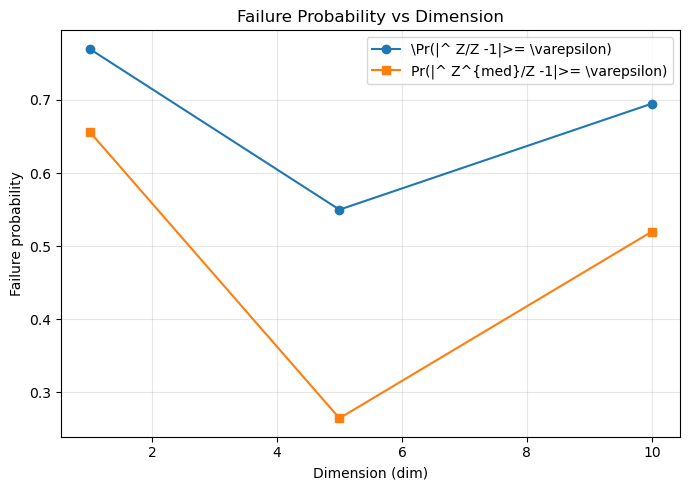

In [73]:
# Cell 8: Summary for plotting
summary = df_splits.dropna(subset=["failure_prob"]).copy()
summary = summary.sort_values("dim")

dims = summary["dim"].values
prob_simple = summary["failure_prob"].values
prob_median = summary["failure_prob_med"].values

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(dims, prob_simple, marker="o", label=r"\Pr(|^ Z/Z -1|>= \varepsilon)")
ax.plot(dims, prob_median, marker="s", label=r"Pr(|^ Z^{med}/Z -1|>= \varepsilon)")
ax.set_xlabel("Dimension (dim)")
ax.set_ylabel("Failure probability")
ax.set_title("Failure Probability vs Dimension")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

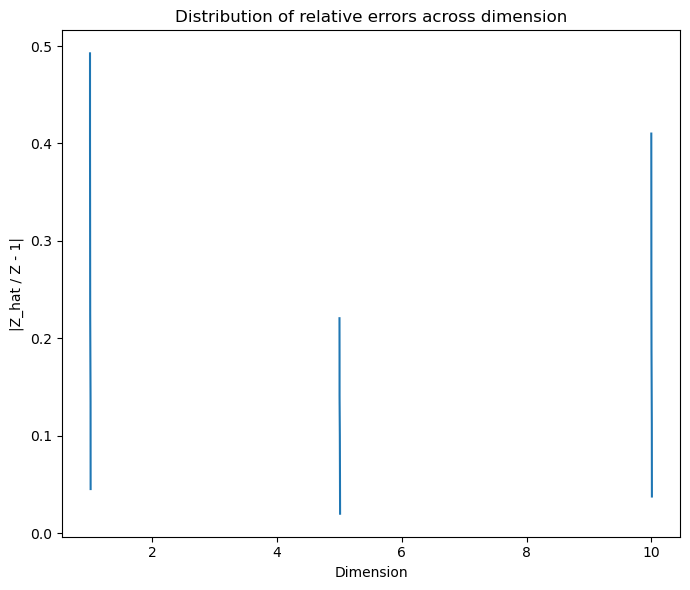

In [74]:
# Cell 9: Ridge-like histogram per dim (optional)
fig, ax = plt.subplots(figsize=(7,6))
width = 0.01
nbins = 6

# Build a dictionary from df_splits
rel_error_by_dim = {dim_val: np.concatenate(group["rel_error_split"].values, axis=0)
                    for dim_val, group in df_splits.groupby("dim")}

for dim_val in sorted(rel_error_by_dim.keys()):
    errors = rel_error_by_dim[dim_val]
    density, bin_edges = np.histogram(errors, bins=nbins, density=True)
    y_vals = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    density = density / density.max()
    x_vals = dim_val + density * width
    ax.plot(x_vals, y_vals, color="tab:blue")
    ax.fill_betweenx(y_vals, dim_val, x_vals, alpha=0.3)
ax.set_xlabel("Dimension")
ax.set_ylabel("|Z_hat / Z - 1|")
ax.set_title("Distribution of relative errors across dimension")
plt.tight_layout()
plt.show()

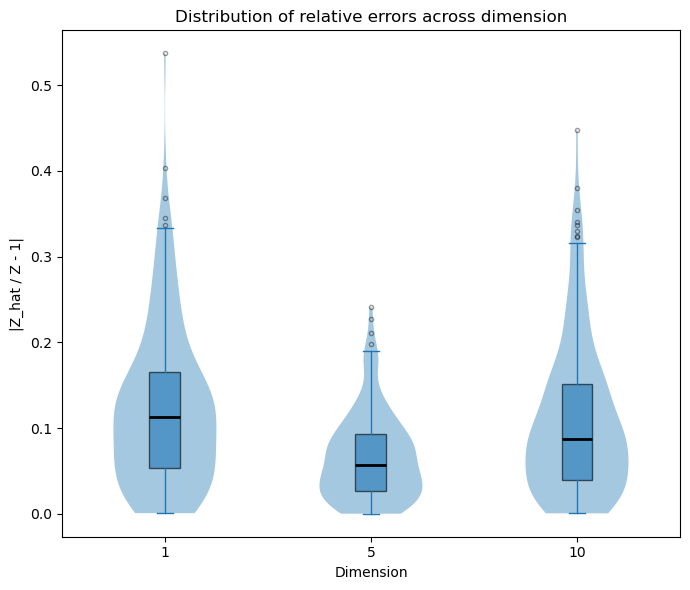

In [60]:
# Cell 10: Violin + box plot per dimension
fig, ax = plt.subplots(figsize=(7,6))
dims_sorted = sorted(rel_error_by_dim.keys())
data = [rel_error_by_dim[dim_val] for dim_val in dims_sorted]

parts = ax.violinplot(data, positions=range(len(dims_sorted)),
                      showmedians=False, showextrema=False)
for pc in parts["bodies"]:
    pc.set_facecolor("tab:blue")
    pc.set_alpha(0.4)

bp = ax.boxplot(data, positions=range(len(dims_sorted)),
                widths=0.15, patch_artist=True,
                medianprops=dict(color="black", linewidth=2),
                boxprops=dict(facecolor="tab:blue", alpha=0.6),
                whiskerprops=dict(color="tab:blue"),
                capprops=dict(color="tab:blue"),
                flierprops=dict(marker="o", markersize=3,
                                color="tab:blue", alpha=0.4))

ax.set_xticks(range(len(dims_sorted)))
ax.set_xticklabels([str(d) for d in dims_sorted])
ax.set_xlabel("Dimension")
ax.set_ylabel("|Z_hat / Z - 1|")
ax.set_title("Distribution of relative errors across dimension")
plt.tight_layout()
plt.show()

In [ ]:
df_splits[df_splits['dim']==10]